Install Required Libraries

In [1]:
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git
!pip install diffusers transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.9 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-77p09cjw
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-77p09cjw
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=4adb5f592fa41cc12a9ab0d956e03303728d7dfd37c8d3564bbc754b0f2a490c
  Stored in directory: /tmp/pip-ephem-wheel-cache-yck8fos8/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


Import Necessary Libraries

In [2]:
import torch
import clip
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from diffusers import StableDiffusionPipeline
from torch import nn, optim
from torchvision import transforms
from torchvision.utils import save_image

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Load CLIP Model

In [3]:
# Load CLIP model
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

100%|███████████████████████████████████████| 338M/338M [00:05<00:00, 70.4MiB/s]


Implement CLIP-Guided Image Generation

I will use Stable Diffusion with CLIP guidance for better text-to-image generation:

In [4]:
def generate_with_clip_guidance(prompt, num_images=1, steps=50, guidance_scale=7.5):
    # Generate initial images
    images = pipe(
        prompt,
        num_inference_steps=steps,
        guidance_scale=guidance_scale,
        num_images_per_prompt=num_images
    ).images

    # If only generating one image, return it directly
    if num_images == 1:
        return images[0]

    # CLIP-based ranking of generated images (for multiple images)
    text_input = clip.tokenize([prompt]).to(device)
    with torch.no_grad():
        text_features = model.encode_text(text_input)

    best_image = None
    best_score = -1

    for img in images:
        # Preprocess image for CLIP
        image_input = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            image_features = model.encode_image(image_input)

        # Calculate similarity
        similarity = (image_features @ text_features.T).item()

        if similarity > best_score:
            best_score = similarity
            best_image = img

    return best_image

Generate Cats and Dogs from Text Prompts

Now let's create some examples:

In [6]:
from diffusers import StableDiffusionPipeline
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16 if device == "cuda" else torch.float32
)
pipe = pipe.to(device)

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

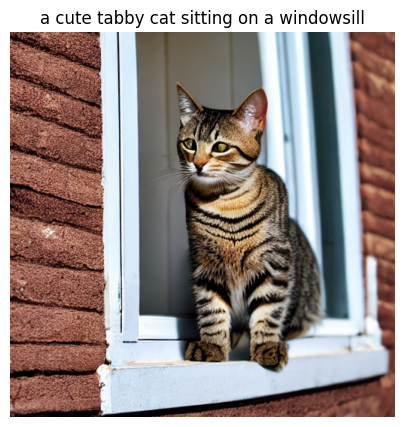

  0%|          | 0/50 [00:00<?, ?it/s]

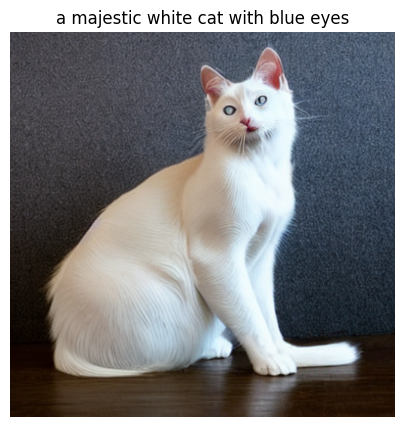

  0%|          | 0/50 [00:00<?, ?it/s]

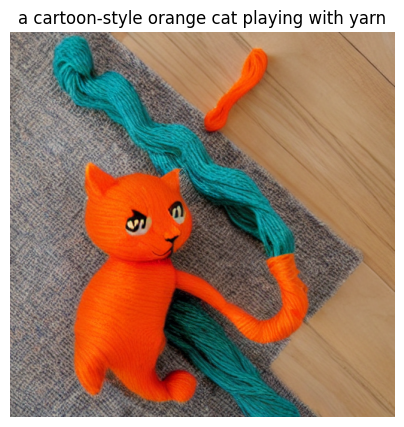

  0%|          | 0/50 [00:00<?, ?it/s]

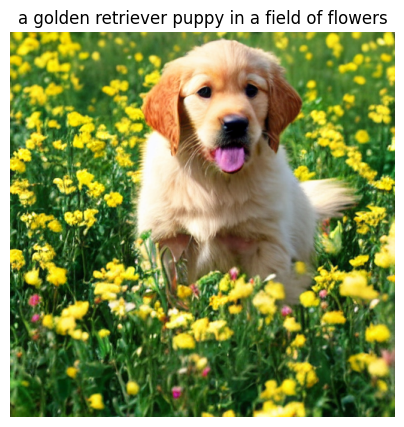

  0%|          | 0/50 [00:00<?, ?it/s]

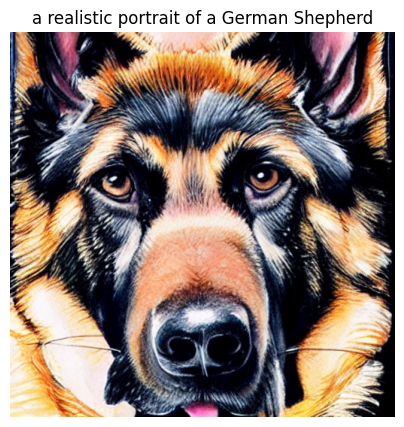

  0%|          | 0/50 [00:00<?, ?it/s]

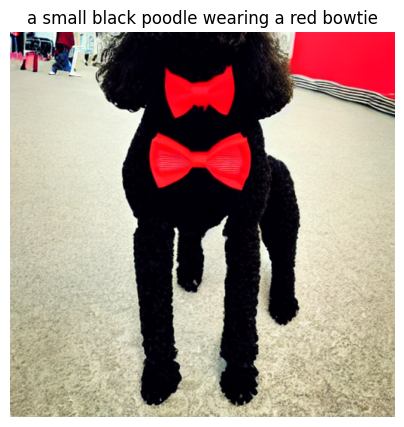

In [7]:
# Generate a cat
cat_prompts = [
    "a cute tabby cat sitting on a windowsill",
    "a majestic white cat with blue eyes",
    "a cartoon-style orange cat playing with yarn"
]

for prompt in cat_prompts:
    generated_image = generate_with_clip_guidance(prompt)
    plt.figure(figsize=(5,5))
    plt.imshow(generated_image)
    plt.title(prompt)
    plt.axis('off')
    plt.show()

# Generate a dog
dog_prompts = [
    "a golden retriever puppy in a field of flowers",
    "a realistic portrait of a German Shepherd",
    "a small black poodle wearing a red bowtie"
]

for prompt in dog_prompts:
    generated_image = generate_with_clip_guidance(prompt)
    plt.figure(figsize=(5,5))
    plt.imshow(generated_image)
    plt.title(prompt)
    plt.axis('off')
    plt.show()

In [8]:
# Save an example image
generated_image = generate_with_clip_guidance("a cute cat and dog playing together")
generated_image.save("cat_dog_playing.png")

  0%|          | 0/50 [00:00<?, ?it/s]